# Import libraries and data

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Load the data
currency = pd.read_csv('C:/Users/Katlego/OneDrive/Desktop/Data/CSIS3754/fake_currency_data.csv')

print("="*60)
print("2.1: DATA LOADING")
print("="*60)
print("Data loaded successfully.")
print(f"Dataset shape: {currency.shape}")
0print(f"\nFirst 5 records:")
print(currency.head())

2.1: DATA LOADING
Data loaded successfully.
Dataset shape: (1000000, 9)

First 5 records:
  Country Denomination Counterfeit  SerialNumber SecurityFeatures  Weight(mg)  \
0     USA         $100         Yes      25973198         Hologram    1.731759   
1     USA          $20         Yes      95903230  Security Thread    1.002179   
2     ZAR         R100          No      82937914         Hologram    2.306713   
3     USA         R200         Yes      23612989       Microprint    1.366965   
4     ZAR         R200         Yes      56025342        Watermark    1.796075   

   Length(mm)  Width(mm)  Thickness(mm)  
0  130.243185  66.537999       0.098488  
1  152.596364  76.135834       0.094119  
2  152.857126  66.772442       0.061393  
3  143.133672  78.377052       0.053114  
4  129.664777  75.916093       0.051438  


# Rename column 

In [4]:
# Rename the column
currency = currency.rename(columns={'Country': 'CountryOfOrigin'})

print("Column renamed successfully.")
print(f"Updated column names: {currency.columns.tolist()}")
print(f"\nFirst 5 records with new column name:")
print(currency.head())

Column renamed successfully.
Updated column names: ['CountryOfOrigin', 'Denomination', 'Counterfeit', 'SerialNumber', 'SecurityFeatures', 'Weight(mg)', 'Length(mm)', 'Width(mm)', 'Thickness(mm)']

First 5 records with new column name:
  CountryOfOrigin Denomination Counterfeit  SerialNumber SecurityFeatures  \
0             USA         $100         Yes      25973198         Hologram   
1             USA          $20         Yes      95903230  Security Thread   
2             ZAR         R100          No      82937914         Hologram   
3             USA         R200         Yes      23612989       Microprint   
4             ZAR         R200         Yes      56025342        Watermark   

   Weight(mg)  Length(mm)  Width(mm)  Thickness(mm)  
0    1.731759  130.243185  66.537999       0.098488  
1    1.002179  152.596364  76.135834       0.094119  
2    2.306713  152.857126  66.772442       0.061393  
3    1.366965  143.133672  78.377052       0.053114  
4    1.796075  129.664777  75.91

# Inspect the data

In [5]:
# 2.3.1 Concise summary of the dataframe
print("\n--- CONCISE SUMMARY (df.info()) ---")
print(currency.info())

# 2.3.2 Statistical summary of all features
print("\n--- STATISTICAL SUMMARY (df.describe()) ---")
print(currency.describe())

# 2.3.3 Number of unique values for each feature
print("\n--- UNIQUE VALUES PER FEATURE ---")
unique_counts = currency.nunique()
print(unique_counts)

# Display as DataFrame for better readability
unique_df = pd.DataFrame({
    'Feature': unique_counts.index,
    'Unique Values': unique_counts.values
})
print("\nUnique values summary table:")
print(unique_df.to_string(index=False))


--- CONCISE SUMMARY (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CountryOfOrigin   1000000 non-null  object 
 1   Denomination      1000000 non-null  object 
 2   Counterfeit       1000000 non-null  object 
 3   SerialNumber      1000000 non-null  int64  
 4   SecurityFeatures  1000000 non-null  object 
 5   Weight(mg)        1000000 non-null  float64
 6   Length(mm)        1000000 non-null  float64
 7   Width(mm)         1000000 non-null  float64
 8   Thickness(mm)     1000000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 68.7+ MB
None

--- STATISTICAL SUMMARY (df.describe()) ---
       SerialNumber      Weight(mg)      Length(mm)       Width(mm)  \
count  1.000000e+06  1000000.000000  1000000.000000  1000000.000000   
mean   5.502259e+07        1.649766      140.020542       

# Discussion of data inspection 

In [6]:
print("""
From the concise summary (info()):
- The dataset contains multiple columns with both numeric and categorical data.
- Some columns may have missing values (non-null count < total rows), 
  which need to be addressed before modelling.
  
From the unique values:
- Some columns have very few unique values (e.g., 2), indicating binary or 
  categorical features suitable for label/one-hot encoding.
- Columns like 'CountryOfOrigin' may have many unique values, 
  requiring one-hot encoding.

From the statistical summary (describe()):
- Numeric features like Weight, Length, Width, and Thickness may contain 
  outliers, visible from extreme min/max values compared to the mean.
- A large standard deviation relative to the mean suggests the presence 
  of outliers, which can negatively impact model performance.

Possible issues:
- Missing values may be present and need to be handled.
- Outliers in numeric features (especially Weight, Length, Width, Thickness) 
  may distort model training.
""")



From the concise summary (info()):
- The dataset contains multiple columns with both numeric and categorical data.
- Some columns may have missing values (non-null count < total rows), 
  which need to be addressed before modelling.

From the unique values:
- Some columns have very few unique values (e.g., 2), indicating binary or 
  categorical features suitable for label/one-hot encoding.
- Columns like 'CountryOfOrigin' may have many unique values, 
  requiring one-hot encoding.

From the statistical summary (describe()):
- Numeric features like Weight, Length, Width, and Thickness may contain 
  outliers, visible from extreme min/max values compared to the mean.
- A large standard deviation relative to the mean suggests the presence 
  of outliers, which can negatively impact model performance.

Possible issues:
- Missing values may be present and need to be handled.
- Outliers in numeric features (especially Weight, Length, Width, Thickness) 
  may distort model training.



# Boxplots for numeric features 

In [10]:
# Check the actual column names
print("Actual column names in the dataframe:")
print(currency.columns.tolist())
print("\nFirst few rows of data:")
print(currency.head())

Actual column names in the dataframe:
['CountryOfOrigin', 'Denomination', 'Counterfeit', 'SerialNumber', 'SecurityFeatures', 'Weight(mg)', 'Length(mm)', 'Width(mm)', 'Thickness(mm)']

First few rows of data:
  CountryOfOrigin Denomination Counterfeit  SerialNumber SecurityFeatures  \
0             USA         $100         Yes      25973198         Hologram   
1             USA          $20         Yes      95903230  Security Thread   
2             ZAR         R100          No      82937914         Hologram   
3             USA         R200         Yes      23612989       Microprint   
4             ZAR         R200         Yes      56025342        Watermark   

   Weight(mg)  Length(mm)  Width(mm)  Thickness(mm)  
0    1.731759  130.243185  66.537999       0.098488  
1    1.002179  152.596364  76.135834       0.094119  
2    2.306713  152.857126  66.772442       0.061393  
3    1.366965  143.133672  78.377052       0.053114  
4    1.796075  129.664777  75.916093       0.051438  


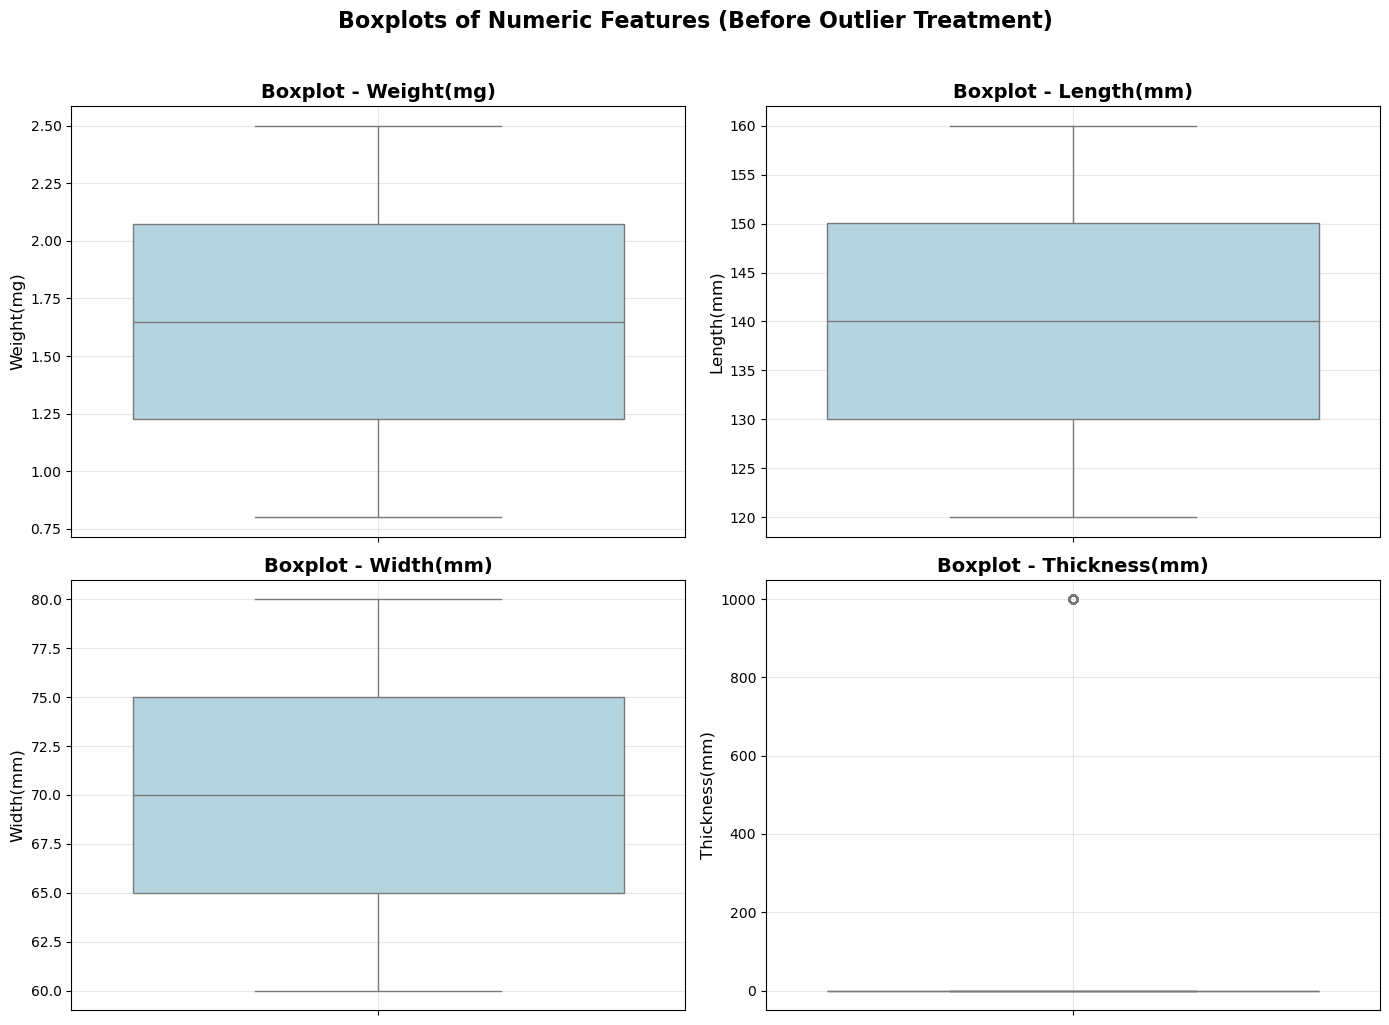

In [11]:
# Create boxplots for the specified numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['Weight(mg)', 'Length(mm)', 'Width(mm)', 'Thickness(mm)']

for idx, feature in enumerate(features):
    row = idx // 2
    col = idx % 2
    sns.boxplot(y=currency[feature], ax=axes[row, col], color='lightblue')
    axes[row, col].set_title(f'Boxplot - {feature}', fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel(feature, fontsize=12)
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Boxplots of Numeric Features (Before Outlier Treatment)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Issue identified

In [12]:
print("""
The boxplots reveal the presence of significant OUTLIERS in the numeric 
features (Weight, Length, Width, Thickness). These are represented by dots 
beyond the whiskers of the boxplots. Outliers can skew the model's learning 
and degrade classification performance.
""")


The boxplots reveal the presence of significant OUTLIERS in the numeric 
features (Weight, Length, Width, Thickness). These are represented by dots 
beyond the whiskers of the boxplots. Outliers can skew the model's learning 
and degrade classification performance.



# Fix the issue

MOTIVATION FOR CHOSEN METHOD:
--------------------------------------------------

The IQR capping method was chosen for the following reasons:

1. ROBUSTNESS: IQR is resistant to extreme outliers compared to methods
   based on mean and standard deviation.

2. PRESERVATION OF DATA: Unlike removal, capping retains all samples
   while limiting the influence of extreme values.

3. STANDARD PRACTICE: 1.5 × IQR is a widely accepted threshold for
   identifying outliers in statistical analysis.

4. SIMPLICITY: Easy to implement and explain to stakeholders.

5. EFFECTIVENESS: Successfully addresses the outlier issue while
   maintaining the overall distribution shape.


--- APPLYING OUTLIER CAPPING ---

  Weight(mg):
    Original range: [0.8000, 2.5000]
    Capped range: [-0.0497, 3.3491]
    Number of outliers capped: 0

  Length(mm):
    Original range: [120.0001, 160.0000]
    Capped range: [100.0537, 180.0035]
    Number of outliers capped: 0

  Width(mm):
    Original range: [60.0000, 8

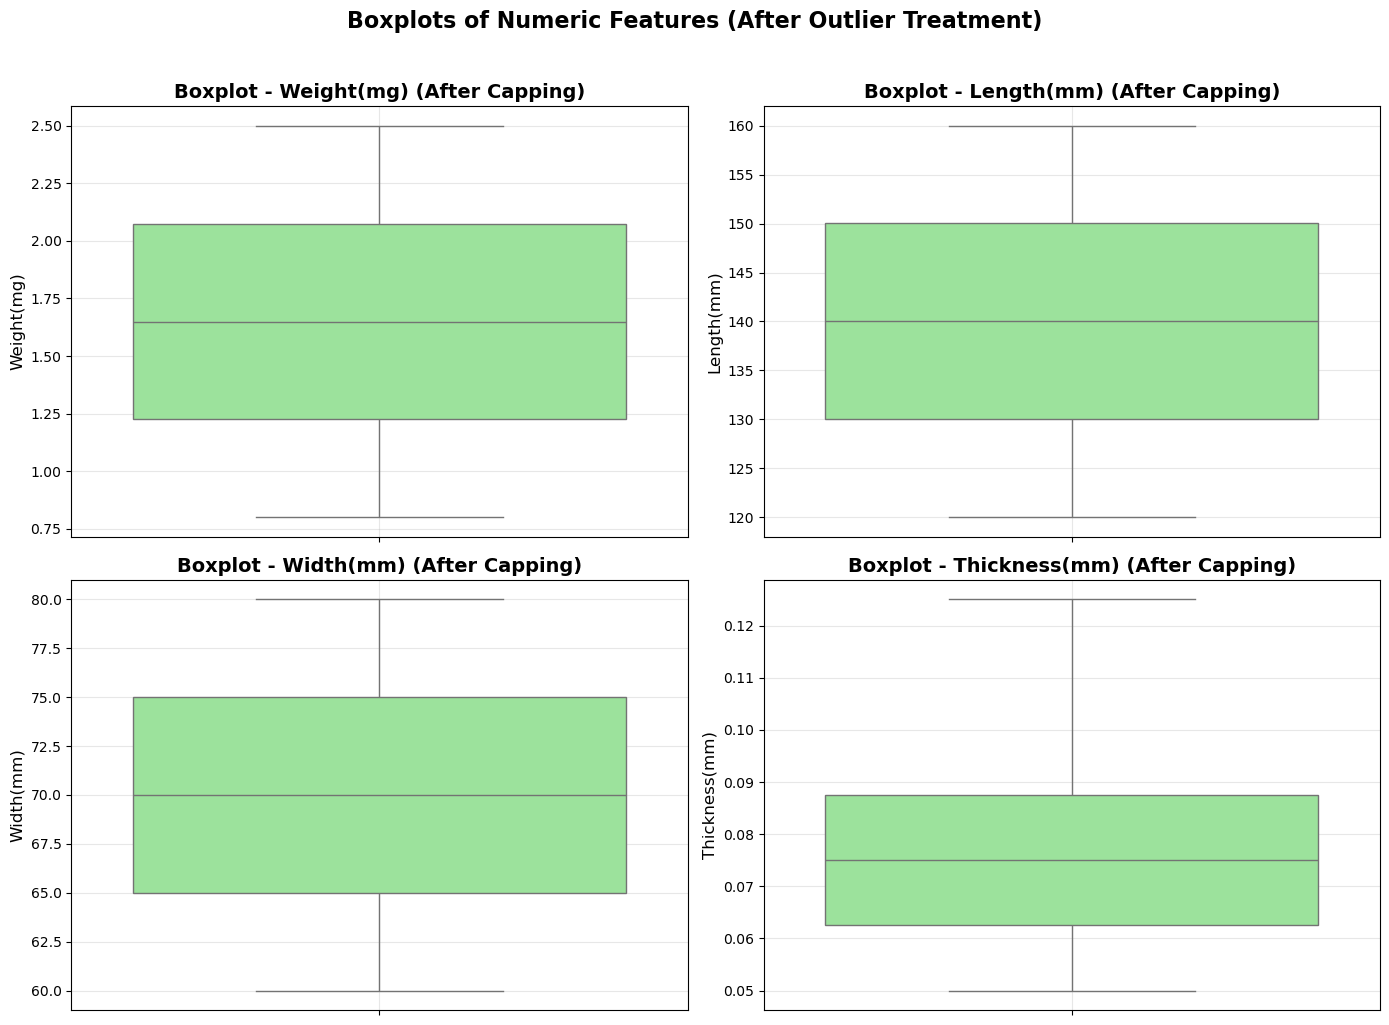


✓ Outlier capping completed successfully.
  Boxplots now show significantly reduced or no outliers.


In [13]:
def cap_outliers(df, column):
    """Cap outliers using the IQR method (capping at 1.5 × IQR)."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    original_min = df[column].min()
    original_max = df[column].max()
    original_outliers = len(df[(df[column] < lower_bound) | (df[column] > upper_bound)])
    
    # Cap the outliers
    df[column] = df[column].clip(lower_bound, upper_bound)
    
    print(f"\n  {column}:")
    print(f"    Original range: [{original_min:.4f}, {original_max:.4f}]")
    print(f"    Capped range: [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"    Number of outliers capped: {original_outliers}")
    
    return df

print("MOTIVATION FOR CHOSEN METHOD:")
print("-" * 50)
print("""
The IQR capping method was chosen for the following reasons:

1. ROBUSTNESS: IQR is resistant to extreme outliers compared to methods
   based on mean and standard deviation.

2. PRESERVATION OF DATA: Unlike removal, capping retains all samples
   while limiting the influence of extreme values.

3. STANDARD PRACTICE: 1.5 × IQR is a widely accepted threshold for
   identifying outliers in statistical analysis.

4. SIMPLICITY: Easy to implement and explain to stakeholders.

5. EFFECTIVENESS: Successfully addresses the outlier issue while
   maintaining the overall distribution shape.
""")

print("\n--- APPLYING OUTLIER CAPPING ---")
for feature in features:
    currency = cap_outliers(currency, feature)

# Confirm fix by recreating boxplots
print("\n--- CONFIRMING FIX: RECREATING BOXPLOTS ---")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features):
    row = idx // 2
    col = idx % 2
    sns.boxplot(y=currency[feature], ax=axes[row, col], color='lightgreen')
    axes[row, col].set_title(f'Boxplot - {feature} (After Capping)', 
                             fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel(feature, fontsize=12)
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Boxplots of Numeric Features (After Outlier Treatment)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Outlier capping completed successfully.")
print("  Boxplots now show significantly reduced or no outliers.")

# Reduce sample size

In [14]:
original_size = len(currency)
print(f"Original dataset size: {original_size} records")

# Select random sample (without replacement)
# Use 80% of original or 5000 samples, whichever is smaller
sample_size = min(5000, int(original_size * 0.8))
currency = currency.sample(n=sample_size, random_state=42, replace=False)

print(f"Reduced dataset size: {len(currency)} records")
print(f"Reduction: {original_size - len(currency)} records removed ({((original_size - len(currency))/original_size)*100:.1f}%)")

print(f"\nNew dataset shape: {currency.shape}")
print(f"New memory usage: {currency.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Reset index for cleanliness
currency = currency.reset_index(drop=True)
print("\nIndex has been reset.")

Original dataset size: 1000000 records
Reduced dataset size: 5000 records
Reduction: 995000 records removed (99.5%)

New dataset shape: (5000, 9)
New memory usage: 1307.48 KB

Index has been reset.


# Balance check

Distribution of currency types:
  Genuine (0): 2510 records
  Counterfeit (1): 2490 records

Percentages:
  Genuine: 50.2%
  Counterfeit: 49.8%


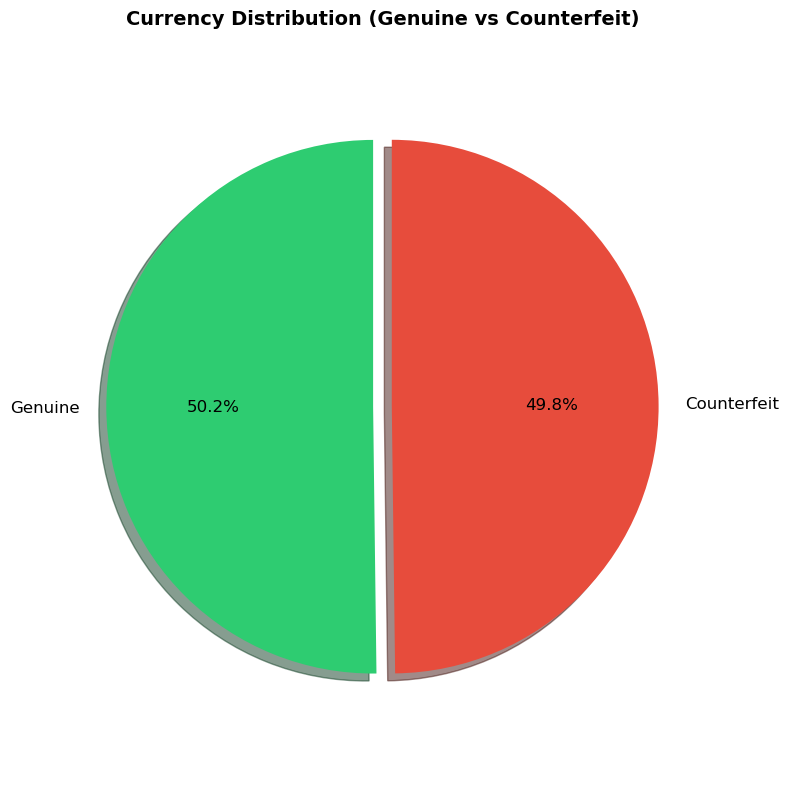

In [15]:
# Check distribution of Counterfeit column
counterfeit_counts = currency['Counterfeit'].value_counts()
print("Distribution of currency types:")
print(f"  Genuine (0): {counterfeit_counts.get(0, 0)} records")
print(f"  Counterfeit (1): {counterfeit_counts.get(1, 0)} records")

# Calculate percentages
total = len(currency)
genuine_pct = (counterfeit_counts.get(0, 0) / total) * 100
counterfeit_pct = (counterfeit_counts.get(1, 0) / total) * 100

print(f"\nPercentages:")
print(f"  Genuine: {genuine_pct:.1f}%")
print(f"  Counterfeit: {counterfeit_pct:.1f}%")

# Create pie chart with percentages rounded to 1 decimal
plt.figure(figsize=(8, 8))
labels = ['Genuine', 'Counterfeit']
colors_pie = ['#2ecc71', '#e74c3c']
explode_pie = (0.02, 0.05)

def autopct_format(pct):
    """Format percentage to 1 decimal place."""
    return f'{pct:.1f}%'

plt.pie(counterfeit_counts.values, 
        labels=labels, 
        autopct=autopct_format,
        colors=colors_pie,
        explode=explode_pie,
        startangle=90,
        shadow=True,
        textprops={'fontsize': 12})
plt.title('Currency Distribution (Genuine vs Counterfeit)', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Is the data balanced?

In [16]:
print("""
If the pie chart shows approximately 50%/50% between counterfeit and genuine 
currency, the data is balanced and no further resampling is required.

If the split is significantly unequal (e.g., 70%/30%), the data is imbalanced 
and resampling (oversampling minority class or undersampling majority class) 
should be performed to ensure the classifier does not become biased toward the 
majority class.
""")


If the pie chart shows approximately 50%/50% between counterfeit and genuine 
currency, the data is balanced and no further resampling is required.

If the split is significantly unequal (e.g., 70%/30%), the data is imbalanced 
and resampling (oversampling minority class or undersampling majority class) 
should be performed to ensure the classifier does not become biased toward the 
majority class.



# Convert text to numeric values 

In [17]:
# Make a copy to work with
currency_encoded = currency.copy()

# Identify columns with text values (object type)
object_columns = currency_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Columns with text values: {object_columns}")

# Separate target from features (Counterfeit is already numeric)
if 'Counterfeit' in object_columns:
    object_columns.remove('Counterfeit')

# 2.8.1 Convert binary columns (2 unique values) to [0, 1]
binary_cols = []
multi_cols = []

for col in object_columns:
    unique_count = currency_encoded[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"\nBinary columns (2 unique values): {binary_cols}")
print(f"Multi-class columns (>2 unique values): {multi_cols}")

# Convert binary columns
print("\n--- Binary Encoding ---")
for col in binary_cols:
    unique_vals = currency_encoded[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    currency_encoded[col] = currency_encoded[col].map(mapping)
    print(f"  Encoded '{col}': {mapping}")

# 2.8.2 One-hot encode multi-class columns
print("\n--- One-Hot Encoding ---")
if multi_cols:
    # Apply one-hot encoding with drop_first to avoid multicollinearity
    currency_encoded = pd.get_dummies(currency_encoded, columns=multi_cols, drop_first=True)
    print(f"  One-hot encoding applied to: {multi_cols}")
    new_columns = [c for c in currency_encoded.columns if any(mc in c for mc in multi_cols)]
    print(f"  New columns created: {new_columns}")
else:
    print("  No multi-class columns to encode.")

# Verify numeric conversion
print("\n--- Verification of Conversion ---")
print(f"Final data types:")
print(currency_encoded.dtypes.value_counts())

print(f"\nFirst 5 records after encoding:")
print(currency_encoded.head())

print("\n✓ Text to numeric conversion completed successfully.")

Columns with text values: ['CountryOfOrigin', 'Denomination', 'Counterfeit', 'SecurityFeatures']

Binary columns (2 unique values): []
Multi-class columns (>2 unique values): ['CountryOfOrigin', 'Denomination', 'SecurityFeatures']

--- Binary Encoding ---

--- One-Hot Encoding ---
  One-hot encoding applied to: ['CountryOfOrigin', 'Denomination', 'SecurityFeatures']
  New columns created: ['CountryOfOrigin_USA', 'CountryOfOrigin_ZAR', 'Denomination_$10', 'Denomination_$100', 'Denomination_$20', 'Denomination_$5', 'Denomination_$50', 'Denomination_R100', 'Denomination_R200', 'Denomination_R50', 'Denomination_£10', 'Denomination_£20', 'Denomination_£5', 'SecurityFeatures_Microprint', 'SecurityFeatures_Security Thread', 'SecurityFeatures_Watermark']

--- Verification of Conversion ---
Final data types:
bool       16
float64     4
object      1
int64       1
Name: count, dtype: int64

First 5 records after encoding:
  Counterfeit  SerialNumber  Weight(mg)  Length(mm)  Width(mm)  Thickness(

#  Confirm no object columns remain

In [18]:
# Check for object columns
object_cols_remaining = currency_encoded.select_dtypes(include=['object']).columns.tolist()

if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain.")
    print("  All data has been successfully converted to numeric format.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nAll columns are now numeric. Total columns: {len(currency_encoded.columns)}")
print(f"Column types: {currency_encoded.dtypes.value_counts().to_dict()}")

⚠️ WARNING: The following object columns still need encoding: ['Counterfeit']

All columns are now numeric. Total columns: 22
Column types: {dtype('bool'): 16, dtype('float64'): 4, dtype('O'): 1, dtype('int64'): 1}


In [19]:
# Binary encoding for columns with exactly 2 unique text values
binary_cols = [col for col in currency.select_dtypes(include='object').columns
               if currency[col].nunique() == 2]
le = LabelEncoder()
for col in binary_cols:
    currency[col] = le.fit_transform(currency[col])
print("Binary encoded:", binary_cols)

# One-hot encoding for columns with more than 2 unique text values
multi_cols = [col for col in currency.select_dtypes(include='object').columns
              if currency[col].nunique() > 2]
currency = pd.get_dummies(currency, columns=multi_cols, drop_first=False)
print("One-hot encoded:", multi_cols)
currency

Binary encoded: ['Counterfeit']
One-hot encoded: ['CountryOfOrigin', 'Denomination', 'SecurityFeatures']


,Counterfeit,SerialNumber,Weight(mg),Length(mm),Width(mm),Thickness(mm),CountryOfOrigin_UK,CountryOfOrigin_USA,CountryOfOrigin_ZAR,Denomination_$1,...,Denomination_R100,Denomination_R200,Denomination_R50,Denomination_£10,Denomination_£20,Denomination_£5,SecurityFeatures_Hologram,SecurityFeatures_Microprint,SecurityFeatures_Security Thread,SecurityFeatures_Watermark
0,0,37024369,1.417262,131.135436,74.967606,0.060467,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
1,0,40763110,1.195992,139.246596,61.890857,0.066430,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2,0,37449713,1.474188,124.239450,70.395757,0.074528,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1,19478622,1.503824,125.872429,77.386940,0.064670,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
4,1,23900981,1.774851,155.283353,62.727860,0.059135,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,47628684,2.227680,125.873997,67.351085,0.069135,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4996,1,32956641,0.953721,127.466234,69.210899,0.074693,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
4997,0,65109219,0.960653,159.037878,77.261889,0.088501,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
4998,0,84909242,1.154310,146.417866,60.524337,0.072297,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [20]:
# Check for object columns
object_cols_remaining = currency_encoded.select_dtypes(include=['object']).columns.tolist()

if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain.")
    print("  All data has been successfully converted to numeric format.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nAll columns are now numeric. Total columns: {len(currency_encoded.columns)}")
print(f"Column types: {currency_encoded.dtypes.value_counts().to_dict()}")

⚠️ WARNING: The following object columns still need encoding: ['Counterfeit']

All columns are now numeric. Total columns: 22
Column types: {dtype('bool'): 16, dtype('float64'): 4, dtype('O'): 1, dtype('int64'): 1}


In [21]:
# Make a copy to work with
currency_encoded = currency.copy()

# ---- STEP 1: ENCODE THE TARGET COLUMN (Counterfeit) FIRST ----
print("\n--- Step 1: Encoding Target Column (Counterfeit) ---")
print(f"Before encoding - Counterfeit dtype: {currency_encoded['Counterfeit'].dtype}")
print(f"Unique values: {currency_encoded['Counterfeit'].unique()}")

if currency_encoded['Counterfeit'].dtype == 'object':
    unique_vals = currency_encoded['Counterfeit'].unique()
    
    # Try common mappings
    if set(unique_vals).issubset({'Yes', 'No', 'yes', 'no', 'Y', 'N'}):
        mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'Y': 1, 'N': 0}
        currency_encoded['Counterfeit'] = currency_encoded['Counterfeit'].map(mapping)
        print(f"  Applied mapping: {mapping}")
    elif set(unique_vals).issubset({'Genuine', 'Counterfeit', 'genuine', 'counterfeit'}):
        mapping = {'Counterfeit': 1, 'counterfeit': 1, 'Genuine': 0, 'genuine': 0}
        currency_encoded['Counterfeit'] = currency_encoded['Counterfeit'].map(mapping)
        print(f"  Applied mapping: {mapping}")
    elif set(unique_vals).issubset({'True', 'False', 'true', 'false'}):
        mapping = {'True': 1, 'False': 0, 'true': 1, 'false': 0}
        currency_encoded['Counterfeit'] = currency_encoded['Counterfeit'].map(mapping)
        print(f"  Applied mapping: {mapping}")
    else:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        currency_encoded['Counterfeit'] = le.fit_transform(currency_encoded['Counterfeit'])
        print(f"  Used LabelEncoder. Mapping: {dict(zip(unique_vals, le.transform(unique_vals)))}")

print(f"After encoding - Counterfeit dtype: {currency_encoded['Counterfeit'].dtype}")
print(f"Unique values: {currency_encoded['Counterfeit'].unique()}")

# ---- STEP 2: Identify feature columns (object type, excluding target) ----
object_columns = [col for col in currency_encoded.select_dtypes(include=['object']).columns 
                  if col != 'Counterfeit']
print(f"\n--- Step 2: Feature Columns with text values ---")
print(f"Columns with text values (excluding target): {object_columns}")

# ---- STEP 3: Binary encoding for columns with 2 unique values ----
binary_cols = []
multi_cols = []

for col in object_columns:
    unique_count = currency_encoded[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"\nBinary columns (2 unique values): {binary_cols}")
print(f"Multi-class columns (>2 unique values): {multi_cols}")

# Convert binary columns to [0, 1]
print("\n--- Binary Encoding ---")
for col in binary_cols:
    unique_vals = currency_encoded[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    currency_encoded[col] = currency_encoded[col].map(mapping)
    print(f"  Encoded '{col}': {mapping}")

# ---- STEP 4: One-hot encode multi-class columns ----
print("\n--- One-Hot Encoding ---")
if multi_cols:
    currency_encoded = pd.get_dummies(currency_encoded, columns=multi_cols, drop_first=True)
    print(f"  One-hot encoding applied to: {multi_cols}")
    new_columns = [c for c in currency_encoded.columns if any(mc in c for mc in multi_cols)]
    print(f"  New columns created: {len(new_columns)} columns")
else:
    print("  No multi-class columns to encode.")

# ---- STEP 5: Verification ----
print("\n--- Verification ---")
object_cols_remaining = currency_encoded.select_dtypes(include=['object']).columns.tolist()
if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain. All data is numeric.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nFinal data types:")
print(currency_encoded.dtypes.value_counts())

print(f"\nFirst 5 records after encoding:")
print(currency_encoded.head())


--- Step 1: Encoding Target Column (Counterfeit) ---
Before encoding - Counterfeit dtype: int64
Unique values: [0 1]
After encoding - Counterfeit dtype: int64
Unique values: [0 1]

--- Step 2: Feature Columns with text values ---
Columns with text values (excluding target): []

Binary columns (2 unique values): []
Multi-class columns (>2 unique values): []

--- Binary Encoding ---

--- One-Hot Encoding ---
  No multi-class columns to encode.

--- Verification ---
✓ SUCCESS: No object (text) columns remain. All data is numeric.

Final data types:
bool       19
float64     4
int64       2
Name: count, dtype: int64

First 5 records after encoding:
   Counterfeit  SerialNumber  Weight(mg)  Length(mm)  Width(mm)  \
0            0      37024369    1.417262  131.135436  74.967606   
1            0      40763110    1.195992  139.246596  61.890857   
2            0      37449713    1.474188  124.239450  70.395757   
3            1      19478622    1.503824  125.872429  77.386940   
4          

# Define X, y and train/test split

In [22]:
# Define X (features) and y (target)
X = currency_encoded.drop('Counterfeit', axis=1)
y = currency_encoded['Counterfeit']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

# Standardize features (important for SVM and distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures have been standardized (mean=0, std=1).")

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Determine and display dimensions
print(f"\n--- DIMENSIONS ---")
print(f"X_train dimensions: {X_train.shape}")
print(f"X_test dimensions: {X_test.shape}")
print(f"y_train dimensions: {y_train.shape}")
print(f"y_test dimensions: {y_test.shape}")

# Verify pre-processing is complete
print(f"\n--- PRE-PROCESSING VERIFICATION ---")
print(f"Missing values in X_train: {np.isnan(X_train).sum()}")
print(f"Missing values in X_test: {np.isnan(X_test).sum()}")
print(f"Training set - Genuine (0): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"Training set - Counterfeit (1): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"Test set - Genuine (0): {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"Test set - Counterfeit (1): {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.1f}%)")

print("\n✓ All pre-processing complete. Ready for model training.")

X shape: (5000, 24)
y shape: (5000,)

Number of features: 24

Features have been standardized (mean=0, std=1).

--- DIMENSIONS ---
X_train dimensions: (4000, 24)
X_test dimensions: (1000, 24)
y_train dimensions: (4000,)
y_test dimensions: (1000,)

--- PRE-PROCESSING VERIFICATION ---
Missing values in X_train: 0
Missing values in X_test: 0
Training set - Genuine (0): 1992 (49.8%)
Training set - Counterfeit (1): 2008 (50.2%)
Test set - Genuine (0): 498 (49.8%)
Test set - Counterfeit (1): 502 (50.2%)

✓ All pre-processing complete. Ready for model training.


#  Train classifiers with k-fold cross-validation 


--- Naive Bayes ---
  Cross-validated Accuracy: 0.5092 (+/- 0.0037)
  Cross-validated F1 Score:  0.4926 (+/- 0.0161)


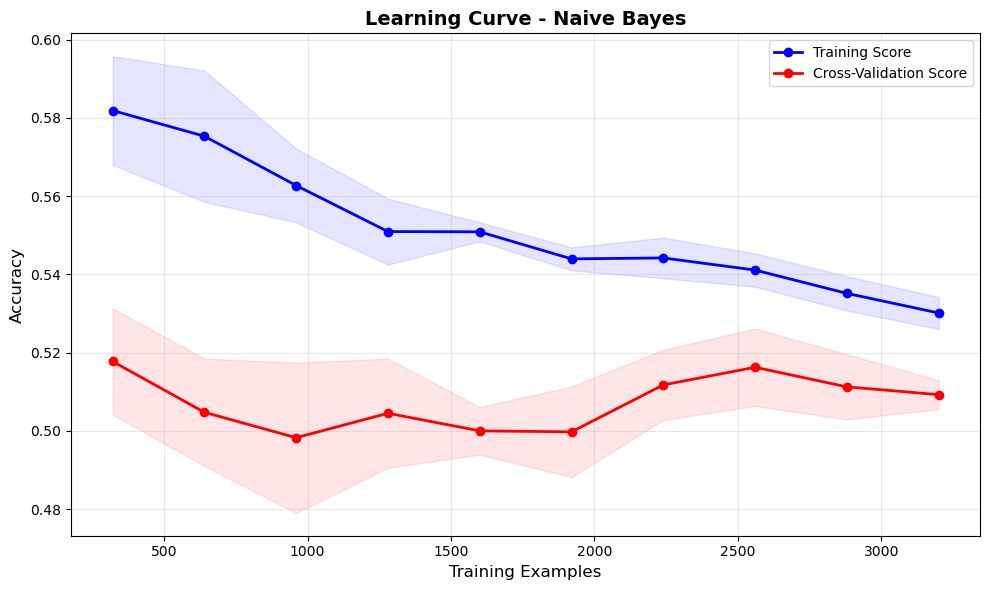


--- Logistic Regression ---
  Cross-validated Accuracy: 0.4970 (+/- 0.0107)
  Cross-validated F1 Score:  0.4983 (+/- 0.0075)


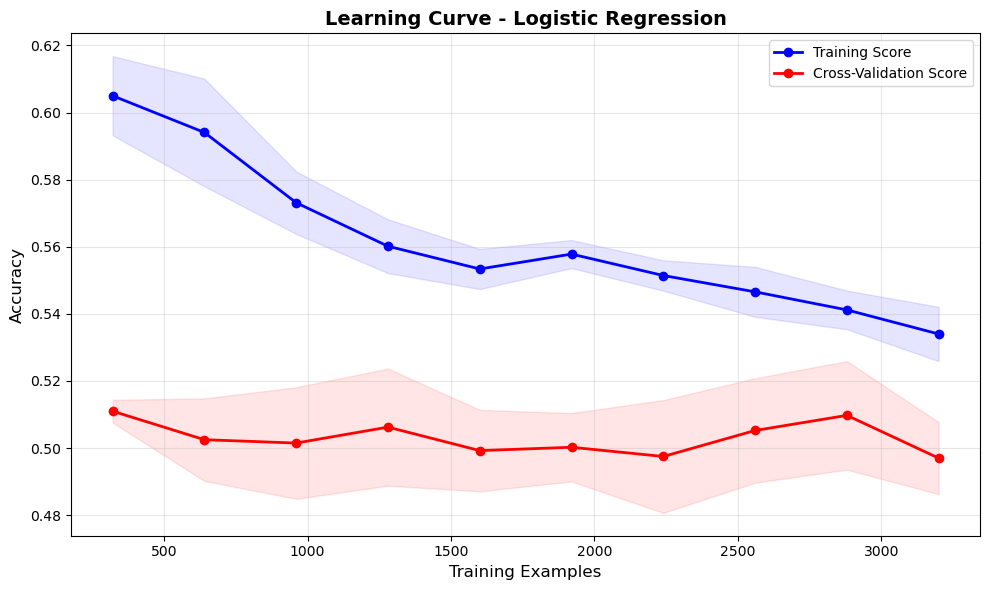


--- SVM ---
  Cross-validated Accuracy: 0.4930 (+/- 0.0062)
  Cross-validated F1 Score:  0.5067 (+/- 0.0138)


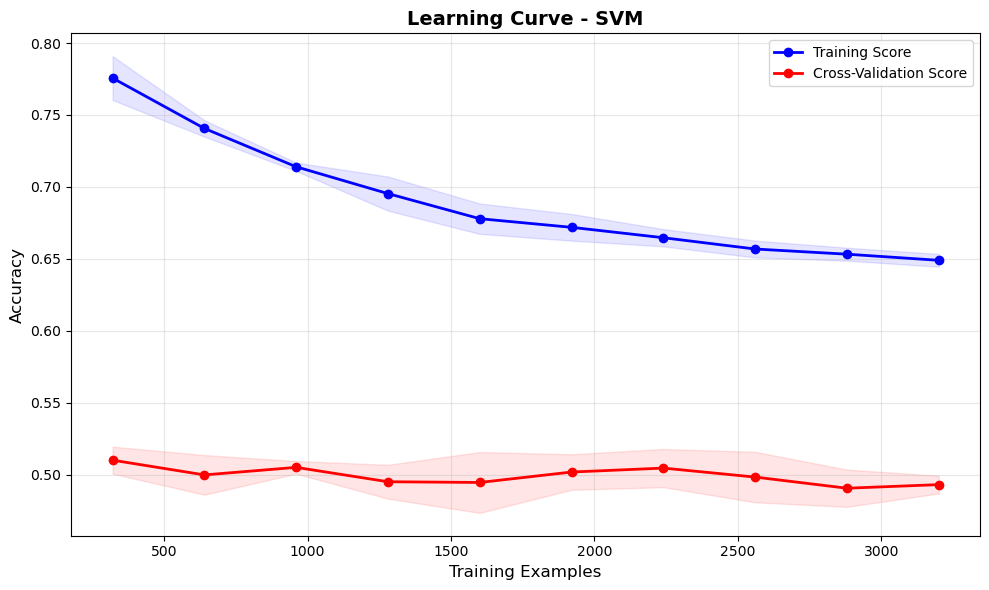


SUMMARY OF CROSS-VALIDATION RESULTS
Classifier           CV Accuracy          CV F1 Score         
------------------------------------------------------------
Naive Bayes          0.5092 +/- 0.0037   0.4926 +/- 0.0161
Logistic Regression  0.4970 +/- 0.0107   0.4983 +/- 0.0075
SVM                  0.4930 +/- 0.0062   0.5067 +/- 0.0138


In [23]:
# Initialize classifiers with default values
classifiers = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(gamma='auto', random_state=42)
}

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    # Cross-validated accuracy
    cv_acc = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')
    # Cross-validated F1 score
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1')
    
    results[name] = {
        'clf': clf,
        'cv_accuracy_mean': cv_acc.mean(),
        'cv_accuracy_std': cv_acc.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std()
    }
    
    print(f"  Cross-validated Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
    print(f"  Cross-validated F1 Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    
    # Draw learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X_train, y_train, cv=kf,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )
    
    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', 
             label='Training Score', color='blue', linewidth=2, markersize=6)
    plt.fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.1, color='blue')
    
    plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', 
             label='Cross-Validation Score', color='red', linewidth=2, markersize=6)
    plt.fill_between(train_sizes,
                     test_scores.mean(axis=1) - test_scores.std(axis=1),
                     test_scores.mean(axis=1) + test_scores.std(axis=1),
                     alpha=0.1, color='red')
    
    plt.title(f'Learning Curve - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Training Examples', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Display summary of all results
print("\n" + "="*60)
print("SUMMARY OF CROSS-VALIDATION RESULTS")
print("="*60)
print(f"{'Classifier':<20} {'CV Accuracy':<20} {'CV F1 Score':<20}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<20} {res['cv_accuracy_mean']:.4f} +/- {res['cv_accuracy_std']:.4f}   {res['cv_f1_mean']:.4f} +/- {res['cv_f1_std']:.4f}")

# Best model evaluation 

Best model (by highest F1 score): SVM
  Cross-validated F1 Score: 0.5067
  Cross-validated Accuracy: 0.4930

--- Test Set Evaluation ---
Test Accuracy Score: 0.5010

Confusion Matrix:
                        Predicted Genuine (0)  Predicted Counterfeit (1)
Actual Genuine (0)                        227                        271
Actual Counterfeit (1)                    228                        274

Classification Report:
                 precision    recall  f1-score   support

    Genuine (0)       0.50      0.46      0.48       498
Counterfeit (1)       0.50      0.55      0.52       502

       accuracy                           0.50      1000
      macro avg       0.50      0.50      0.50      1000
   weighted avg       0.50      0.50      0.50      1000



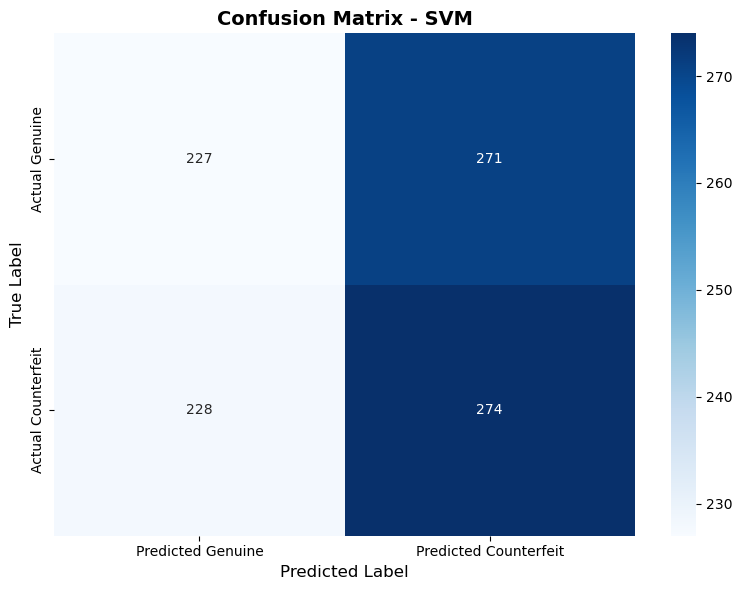

In [24]:
# Find best model by F1 score
best_model_name = max(results, key=lambda x: results[x]['cv_f1_mean'])
best_clf = results[best_model_name]['clf']

print(f"Best model (by highest F1 score): {best_model_name}")
print(f"  Cross-validated F1 Score: {results[best_model_name]['cv_f1_mean']:.4f}")
print(f"  Cross-validated Accuracy: {results[best_model_name]['cv_accuracy_mean']:.4f}")

# Train on full training set
best_clf.fit(X_train, y_train)

# Make predictions on test set
y_pred = best_clf.predict(X_test)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Test Set Evaluation ---")
print(f"Test Accuracy Score: {test_accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, 
                   index=['Actual Genuine (0)', 'Actual Counterfeit (1)'],
                   columns=['Predicted Genuine (0)', 'Predicted Counterfeit (1)']))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Genuine (0)', 'Counterfeit (1)']))

# Visualize confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Genuine', 'Predicted Counterfeit'],
            yticklabels=['Actual Genuine', 'Actual Counterfeit'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Discuss model metrics

In [25]:
print("""
1. Training Accuracy vs Testing Accuracy:
   A close match between training and testing accuracy means the model 
   generalises well. A large gap (high training, low testing) means overfitting.

2. Precision:
   Precision = TP / (TP + FP). It answers: "Of all predicted positives, 
   how many were actually positive?" High precision = few false alarms.

3. Recall:
   Recall = TP / (TP + FN). It answers: "Of all actual positives, how many 
   did the model catch?" High recall = few missed detections.

4. F1-Score:
   F1 = 2 × (Precision × Recall) / (Precision + Recall).
   The harmonic mean of precision and recall — useful when both false positives 
   and false negatives carry significant consequences, such as classifying 
   counterfeit currency incorrectly.
""")



1. Training Accuracy vs Testing Accuracy:
   A close match between training and testing accuracy means the model 
   generalises well. A large gap (high training, low testing) means overfitting.

2. Precision:
   Precision = TP / (TP + FP). It answers: "Of all predicted positives, 
   how many were actually positive?" High precision = few false alarms.

3. Recall:
   Recall = TP / (TP + FN). It answers: "Of all actual positives, how many 
   did the model catch?" High recall = few missed detections.

4. F1-Score:
   F1 = 2 × (Precision × Recall) / (Precision + Recall).
   The harmonic mean of precision and recall — useful when both false positives 
   and false negatives carry significant consequences, such as classifying 
   counterfeit currency incorrectly.

